In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Erosão
Dado uma imagem `I` e um Elemento Estruturante `B`, a erosão de `I` por `B` é definida como: 
$A \ominus B = \{ z \in \mathbb{R}^n \mid (B)_z \subseteq A \}$

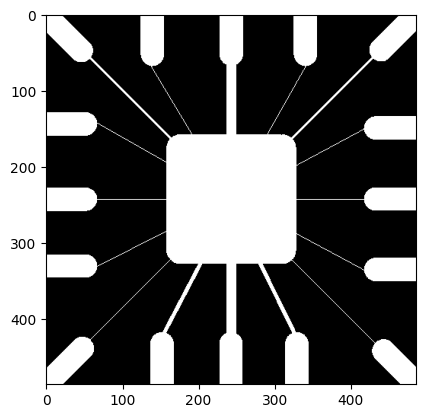

In [2]:
img  = cv2.imread("fig095.tif", 0)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.show()

In [3]:
def erode_slow(img, B, anchor):
    im_h, im_w = img.shape
    B_h, B_w = B.shape
    
    # Image padding
    top = anchor[0]
    bottom = B_h - anchor[0] - 1
    left = anchor[1]
    right = B_w - anchor[1] - 1 
    
    pad_val = np.max(img)
    img_padded = cv2.copyMakeBorder(img, top, bottom, left, right, borderType=cv2.BORDER_CONSTANT, value=int(pad_val))

    # Obtendo as coordenadas relativas onde o elemento estruturante B é 1
    offsets = np.argwhere(B == 1) - anchor
    
    # Inicializa a imagem de saída
    eroded_img = np.zeros_like(img)
    
    # Percorre cada pixel da imagem original
    for i in range(im_h):
        for j in range(im_w):
            # Coordenadas na imagem com padding (compensando o deslocamento do padding)
            pi, pj = i + top, j + left
            
            # Valores da vizinhança
            vals = []
            for dy, dx in offsets:
                vals.append(img_padded[pi + dy, pj + dx])
            
            eroded_img[i, j] = np.min(vals)
            
    return eroded_img

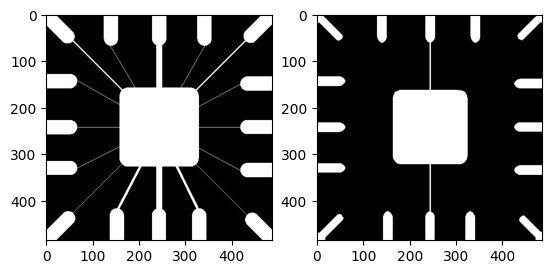

In [4]:
kernel = np.ones((11,11))
h, w = kernel.shape
anchor = (h//2, w//2)
out = erode_slow(img, kernel, anchor)

# plot
fig, axs = plt.subplots(1, 2)
axs[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axs[1].imshow(out, cmap='gray', vmin=0, vmax=255)
plt.show()

In [5]:
from numpy.lib.stride_tricks import sliding_window_view
def erode_fast(img, B, anchor): #anchor é a origem do elemento estruturante
    im_h, im_w = img.shape
    B_h, B_w = B.shape
    
    # Image padding
    top = anchor[0]
    bottom = B_h - anchor[0] - 1
    left = anchor[1]
    right = B_w - anchor[1] - 1 
    
    padded_img = cv2.copyMakeBorder(img, top, bottom, left, right, borderType=cv2.BORDER_CONSTANT, value=int(0))
    
    # sliding_window_view cria uma visão da imagem original deslizando a janela
    # definida pelo elemento estruturante: forma (img_h, img_w, B_h, B_w)
    windows = sliding_window_view(padded_img, (B_h, B_w))
    
    # Maskara que identifica onde o elemento estruturante é 1 (True) e onde ele é 0
    foreground_value = np.max(img)
    mask = (B == foreground_value)
    
    # Aplica a máscara em cada janela mantendo valor original
    # onde a máscara é True e substituí os valores fora da máscara
    # por um valor neutro (máximo)
    masked_windows = np.where(mask, windows, img.max())
    
    # Calcula o mínimo sobre os eixos 2 e 3 (cada janela) onde o B é ativo.
    eroded_image = masked_windows.min(axis=(2, 3))
    
    return eroded_image

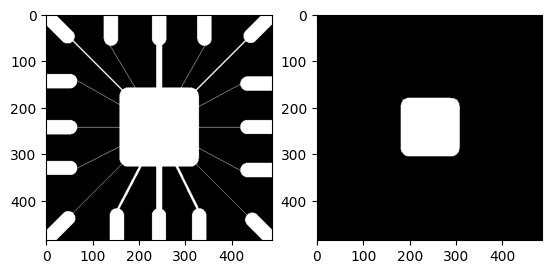

In [6]:
kernel = np.ones((45,45))*255
h, w = kernel.shape
anchor = (h//2, w//2)
out = erode_fast(img, kernel, anchor)

# plot
fig, axs = plt.subplots(1, 2)
axs[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axs[1].imshow(out, cmap='gray', vmin=0, vmax=255)
plt.show()

# Dilatação
Dado uma imagem `I` e um Elemento Estruturante `B`, a dilatação de `I` por `B` é definida como: $A \oplus B = \{ z \in \mathbb{R}^n \mid (\hat{B})_z \cap A \neq \emptyset \}$. A implementação a seguir funciona apenas com elemento estruturante com dimensões impares.

In [7]:
def dilate_fast(img, B, anchor):
    im_h, im_w = img.shape
    B_h, B_w = B.shape
    
    # Image padding
    top = anchor[0]
    bottom = B_h - anchor[0] - 1
    left = anchor[1]
    right = B_w - anchor[1] - 1 
    
    pad_val = np.max(img)
    padded_img = cv2.copyMakeBorder(img, top, bottom, left, right, borderType=cv2.BORDER_CONSTANT, value=0)
    
    # sliding_window_view cria uma visão da imagem original deslizando a janela
    # definida pelo elemento estruturante: forma (img_h, img_w, B_h, B_w)
    windows = sliding_window_view(padded_img, (B_h, B_w))
    
    # Maskara que identifica onde o elemento estruturante é 1 (True) e onde ele é 0
    foreground_value = np.max(img)
    mask = (B == foreground_value)
    
    # Aplica a máscara em cada janela mantendo valor original
    # onde a máscara é True e substituí os valores fora da máscara
    # por um valor neutro (mínimo)
    masked_windows = np.where(mask, windows, img.min())
    
    # Calcula o mínimo sobre os eixos 2 e 3 (cada janela) onde o B é ativo.
    dilated_image = masked_windows.max(axis=(2, 3))
    
    return dilated_image

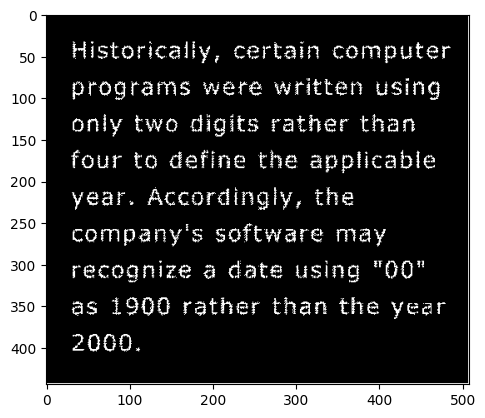

In [8]:
img  = cv2.imread("texto.tif", 0)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.show()

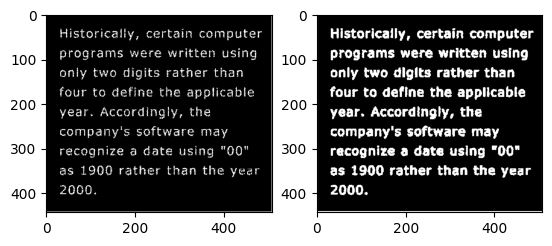

In [10]:
B = np.ones((3,3))*255
out = dilate_fast(img, B, (1, 1))

# plot
fig, axs = plt.subplots(1, 2)
axs[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axs[1].imshow(out, cmap='gray', vmin=0, vmax=255)
plt.show()

# Abertura
Dado uma imagem `I` e um Elemento Estruturante `B`, a abertura de `I` por `B` é definida como: $A \circ B = (A \ominus B) \oplus B$

In [11]:
def openning(img, B, anchor):
    out = erode_fast(img, B, anchor)
    out = dilate_fast(out, B, anchor)
    return out

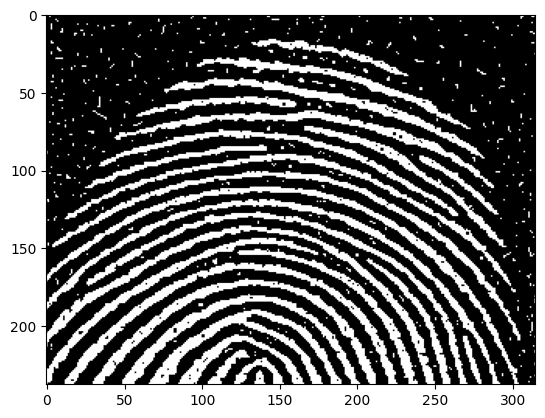

In [12]:
img  = cv2.imread("noisy_fingerprint.tif", 0)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.show()

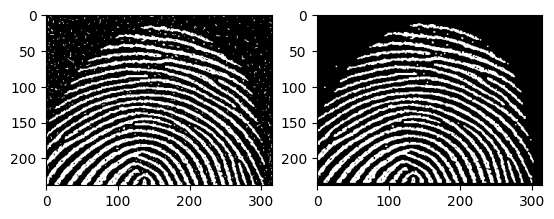

In [19]:
B = np.ones((2,2))*255
out_img = openning(img, B, (0, 0))

# plot
fig, axs = plt.subplots(1, 2)
axs[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axs[1].imshow(out_img, cmap='gray', vmin=0, vmax=255)
plt.show()

# Fechamento
Dado uma imagem `I` e um Elemento Estruturante `B`, a abertura de `I` por `B` é definida como: $A \circ B = (A \oplus B) \ominus B$

In [16]:
def closing(img, B, anchor):
    out = dilate_fast(img, B, anchor)
    out = erode_fast(out, B, anchor)
    return out

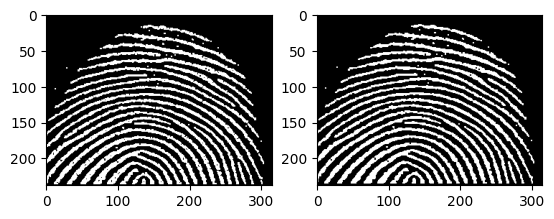

In [17]:
B = np.ones((2,2))*255
out = closing(out_img, B, (0,0))

# plot
fig, axs = plt.subplots(1, 2)
axs[0].imshow(out_img, cmap='gray', vmin=0, vmax=255)
axs[1].imshow(out, cmap='gray', vmin=0, vmax=255)
plt.show()

# Hit-or-Miss transform (não testado!!)
A transformada morfológica de *hit-or-miss* (HMT) é uma ferramenta básica para a detecção de formas. Definição:
$A \circledast B = \{ z \mid (B_1)_z \subseteq A \text{ and } (B_2)_z \subseteq A^{c} \}=(A \ominus B_1) \cap (A^c \ominus B_2)$

In [20]:
import cv2
def htm(img, B1, anchor1, B2, anchor2):
    out1 = erode_fast(img, B1, anchor1)
    img_comp = np.max(img) - img
    out2 = erode_fast(img_comp, B2, anchor2)
    res = cv2.bitwise_and(img1, img2)
    return res

# Extração de Bordas
As bordas de objetos presentes em imagens binárias podem ser obtidas com a seguinte transformação: 
$\beta(A) =(A - (A \ominus B)$

In [25]:
def board_extraction(img, B, anchor):
    eroded_img = erode_fast(img, B, anchor)
    out = img - eroded_img
    return out

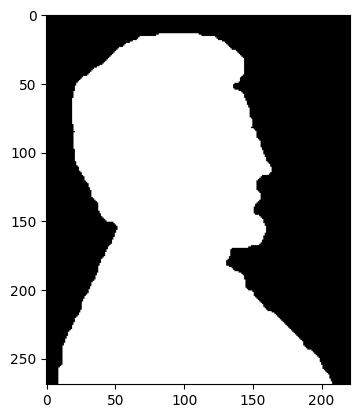

In [26]:
img  = cv2.imread("licoln_penny.tif", 0)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.show()

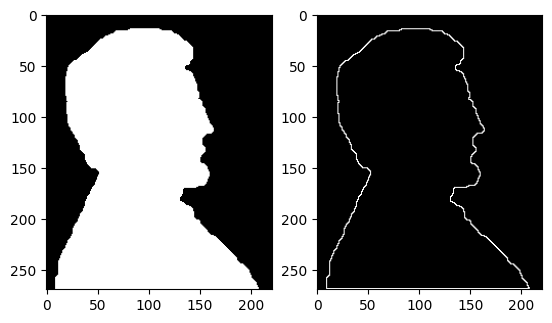

In [28]:
B = np.ones((3,3))*255
out = board_extraction(img, B, (1,1))

# plot
fig, axs = plt.subplots(1, 2)
axs[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axs[1].imshow(out, cmap='gray', vmin=0, vmax=255)
plt.show()

# Preenchimento de Buracos
Primeiro construímos uma matriz $X_0$, zerada, do mesmo tamanho da imagem de entrada $I$. Depois atribuímos a $X_0$, em um ponto de cada buraco, o valor de foreground. Em seguida, num processo iterativo, preenchemos todos os buracos com o valor de foreground: 
$X_k = (X_{k-1}\oplus B) \cap I^{c} $

Se na etapa de iteração k se $X_k = X_{k-1}$, então, $X_k$ contém todos os buracos preenchidos.

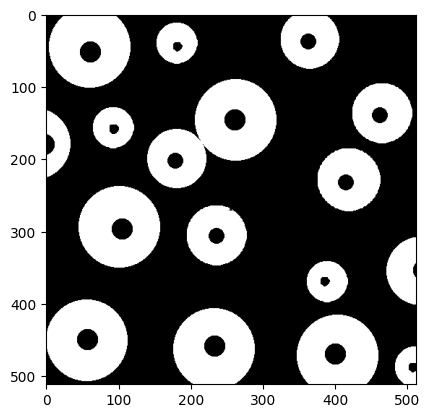

In [29]:
img  = cv2.imread("region-filling.tif", 0)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.show()

iteração 527

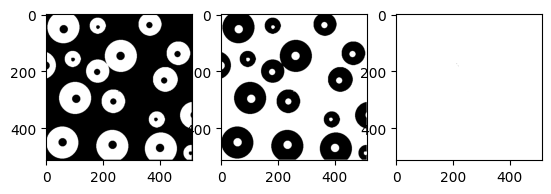

In [30]:
# image complement
padded_img = cv2.copyMakeBorder(img, 1, 1, 1, 1, borderType=cv2.BORDER_CONSTANT, value=0)
foreground_value = np.max(padded_img) # em geral 255
img_comp = foreground_value - padded_img

# initial points
seeds = [(50,62), (47, 182), (38, 366), (178, 6), (160, 95), (202, 182), 
         (145, 262), (232, 415), (138,464), (298, 106), (305, 237), (370, 385),
         (354, 511), (450, 57), (460, 235), (470, 404), (488, 506)]

# seeded image
seeded_img = np.zeros(padded_img.shape, dtype=np.uint8) 

for p in seeds:
    seeded_img[p] = foreground_value  # coloca as sementes
    if img[p] != 0:
        print(f"Semente {p} está no lugar errado! Ela caiu sobre o objeto.")

# Elemento Estruturante (B)
B = np.ones((3,3))*255
B[0,0] = 0
B[0,2] = 0
B[2,0] = 0
B[2,2] = 0

# hole filling loop corrigido
current = seeded_img.copy()
i = 0
while True:
    i += 1
    print(f"\riteração {i}", end="")
    dilated_img = dilate_fast(current, B, (1,1))
    dilated_img = cv2.bitwise_and(dilated_img, img_comp)
    
    if np.array_equal(current, dilated_img):
        break
    current = dilated_img


out = cv2.bitwise_or(padded_img, current)


# plot
fig, axs = plt.subplots(1, 3)
axs[0].imshow(padded_img, cmap='gray', vmin=0, vmax=255)
axs[1].imshow(current, cmap='gray', vmin=0, vmax=255)
axs[2].imshow(out, cmap='gray', vmin=0, vmax=255)
plt.show()

# Componentes Conectados
A extração de componentes conectados envolve duas etapas. Primeiro identificamos os componentes conectados e em seguida fazemos a rotulação.
Começamos formando uma matriz, $X_0$, com 0s, do mesmo tamanho da imagem de entrada $I$. Em seguida, selecionamos um pixel de cada componente conectado e atribuímos 1 ao pixel correspondente em $X_0$. Após as inicializações, iterativamente fazemos uma dilatacão limitada para obter os pixels dos vários componentes conectados:

$X_k = (X_{k-1}\oplus B) \cap I $

Se na etapa de iteração k se $X_k = X_{k-1}$, então, todos os componentes conectados foram obtidos. 

In [ ]:
# Extrator de componentes conectados
class ComponentExtractor:
    def __init__(self, img, seeds):
        
        # normaliza a imagem
        self.img = img / np.max(img)

        # sementes do componente conectado
        self.components = [{(i, j)} for i, j in seeds] # uma lista para cada componente, inicializando com 1 ponto

    # dilata a vizinhança de um pixel
    def _dilate(self, i, j):
        neighbours = set()  # grupo sem repeticao

        # each neighbour pixel is a 
        for k in range(i-1, i+2): # range(1,
            for l in range(j-1, j+2):
                if k >= 0 and k < self.img.shape[0] and l >= 0 and l < self.img.shape[1]:
                    if self.img[k, l] == 1: # test for intersection
                        neighbours.add((k, l))

        return neighbours    

    # returna os componentes conectados
    def extract_components(self):
        for n, comp in enumerate(self.components):
            seed = next(iter(comp))
            neighbours = {seed}
            while len(neighbours) > 0:
                i, j = neighbours.pop()
                new_neighbours = self._dilate(i, j)
                comp.add((i, j))
                neighbours.update(new_neighbours.difference(comp))
            
        return self.components

In [ ]:
img  = cv2.imread("region_filled.tif", 0)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.show()

seeds = [(50,62), (47, 182), (38, 366), (178, 6), (160, 95), (202, 182), (232, 415), (138,464), (298, 106), (305, 237), (370, 385),
         (354, 511), (450, 57), (460, 235), (470, 404), (488, 506)]

obj = ComponentExtractor(img, seeds)

# extract the connected components
components = obj.extract_components()


# visualize
h, w = img.shape
labeled_img = np.zeros((h, w, 3))
for component in components:
    b = np.random.randint(low=0, high=256, size=1).item()
    g = np.random.randint(low=0, high=256, size=1).item()
    r = np.random.randint(low=0, high=256, size=1).item()
    for pixel in component:
        x, y = pixel
        labeled_img[x, y, 0] = r
        labeled_img[x, y, 1] = g
        labeled_img[x, y, 2] = b

labeled_img = labeled_img.astype(np.uint8)
plt.imshow(labeled_img)
plt.show()    
    